# 05 · Ablation, Generalisation & Adversarial Robustness
**Phishing E-mail Detection: A Leakage-Controlled Benchmark of Classical, Deep and Transformer Models**  
*Part VI · Sections 19-21* · MSc Data Science final project · Dr. Spoorthi H S

**In this notebook**
- Architecture, preprocessing and leave-one-feature-out ablations
- Leave-one-source-out generalisation (F1 0.82-0.88) and source-artefact masking test
- Obfuscation attacks: leetspeak, homoglyphs, whitespace injection (F1 0.992 -> 0.673 combined)
- Character-normalisation defence recovers F1 to 0.824 (homoglyphs fully, to 0.992)

> **How to use these notebooks.** The outputs below come from one complete run of the pipeline on a Kaggle Tesla T4 GPU. Every part builds on objects created earlier (the leak-free split, fitted models and their predictions), so the part notebooks are for reading and review. To reproduce the results, run [`00_full_pipeline_run_all.ipynb`](00_full_pipeline_run_all.ipynb) top to bottom.

[← Threat Intelligence: Tactics & IOCs](04_threat_intelligence_tactics_and_iocs.ipynb) · [RAG, Latency, Deployment & LangGraph SOC Agent →](06_rag_latency_deployment_soc_agent.ipynb)

---

<a id="partVI"></a>

<div style="background:#D1495B;color:#fff;padding:16px 24px;border-radius:12px;margin:34px 0 10px 0">
<div style="font-size:0.78em;letter-spacing:.16em;text-transform:uppercase;opacity:.85">Part VI</div>
<div style="font-size:1.7em;font-weight:800;line-height:1.2">Ablation, Generalisation &amp; Robustness</div>
<div style="font-size:0.95em;opacity:.92;margin-top:4px">Sections 19-21 &nbsp;&middot;&nbsp; Research questions: RQ3, RQ5, RQ6</div>
</div>


<a id="sec19"></a>

## 19. Ablation Studies

Three ablations, each isolating one design decision made earlier in the
notebook, so its actual contribution can be measured rather than assumed:
1. **Architecture** -- does the custom model's attention pooling and
   engineered-feature fusion (Section 10) actually help, versus simpler
   alternatives?
2. **Preprocessing** -- does the Section 5 text-cleaning pipeline improve
   the TF-IDF baseline, or would raw text do just as well?
3. **Engineered features** -- which individual hand-crafted feature
   (Section 6) matters most, by leave-one-out validation F1 drop?

### 19.1 Architecture ablation -- attention pooling & feature fusion

Architecture ablation (cfg={'hidden_dim': 128, 'lr': 0.001, 'dropout': 0.3}, 7 epochs each):
  Full (attention + fused features)   best val F1 = 0.9852
  No attention (mean pooling)         best val F1 = 0.9861
  No engineered features (text-only)  best val F1 = 0.9851
  Neither (mean pooling, text-only)   best val F1 = 0.9839


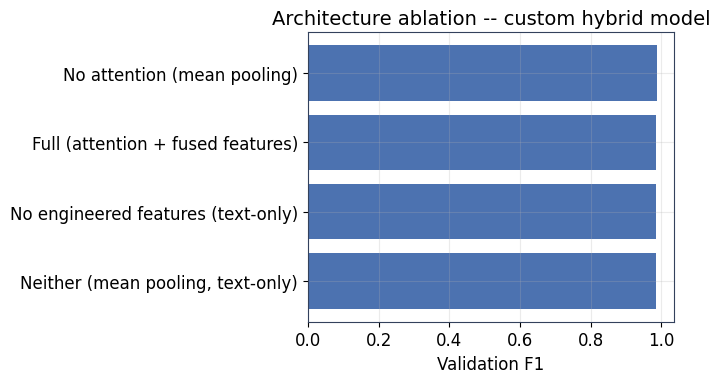

In [67]:
if TORCH_AVAILABLE and "CustomHybridAttnBiGRU" in FITTED_MODELS:
    class AblatableHybridModel(nn.Module):
        '''Same building blocks as CustomHybridModel (Section 10), but attention 
        pooling and engineered-feature fusion can each be switched off, isolating
        their individual contribution.'''
        def __init__(self, vocab_size, n_engineered_feats, embed_dim=128, hidden_dim=128,
                     dropout=0.3, use_attention=True, use_features=True):
            super().__init__()
            self.use_attention = use_attention
            self.use_features = use_features
            self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
            self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
            if use_attention:
                self.attention = AdditiveAttention(hidden_dim * 2)
            clf_in = hidden_dim * 2
            if use_features:
                self.feat_branch = nn.Sequential(
                    nn.Linear(n_engineered_feats, 32), nn.ReLU(), nn.Dropout(dropout))
                clf_in += 32
            self.classifier = nn.Sequential(
                nn.Linear(clf_in, 64), nn.ReLU(), nn.Dropout(dropout), nn.Linear(64, 1))

        def forward(self, token_ids, engineered_feats):
            mask = (token_ids != 0).float()
            emb = self.embedding(token_ids)
            seq_out, _ = self.gru(emb)
            if self.use_attention:
                pooled, _ = self.attention(seq_out, mask)
            else:
                pooled = (seq_out * mask.unsqueeze(-1)).sum(1) / mask.sum(1, keepdim=True).clamp(min=1)
            if self.use_features:
                combined = torch.cat([pooled, self.feat_branch(engineered_feats)], dim=1)
            else:
                combined = pooled
            return self.classifier(combined).squeeze(-1), None

    ABLATION_CFG = best_hybrid_cfg if best_hybrid_cfg is not None else {"hidden_dim": 128, "dropout": 0.3, "lr": 1e-3}
    ABLATION_EPOCHS = max(1, EPOCHS_HYBRID - (1 if not QUICK_RUN else 0))  # keep this section quick

    def run_architecture_ablation(use_attention, use_features, label):
        torch.manual_seed(SEED)
        model = AblatableHybridModel(len(vocab), n_engineered_feats=len(FEATURE_COLS),
                                      hidden_dim=ABLATION_CFG["hidden_dim"], dropout=ABLATION_CFG["dropout"],
                                      use_attention=use_attention, use_features=use_features).to(DEVICE)
        optimizer = torch.optim.Adam(model.parameters(), lr=ABLATION_CFG["lr"])
        criterion = nn.BCEWithLogitsLoss()
        best_f1 = -1
        for _ in range(ABLATION_EPOCHS):
            run_hybrid_epoch(model, hybrid_train_loader, optimizer, criterion, DEVICE, train=True)
            _, val_logits, val_labels = run_hybrid_epoch(model, hybrid_val_loader, optimizer, criterion, DEVICE, train=False)
            val_pred = (1 / (1 + np.exp(-val_logits)) >= 0.5).astype(int)
            best_f1 = max(best_f1, f1_score(val_labels, val_pred))
        print(f"  {label:35s} best val F1 = {best_f1:.4f}")
        return best_f1

    print(f"Architecture ablation (cfg={ABLATION_CFG}, {ABLATION_EPOCHS} epochs each):")
    ablation_arch_results = {
        "Full (attention + fused features)": run_architecture_ablation(True, True, "Full (attention + fused features)"),
        "No attention (mean pooling)": run_architecture_ablation(False, True, "No attention (mean pooling)"),
        "No engineered features (text-only)": run_architecture_ablation(True, False, "No engineered features (text-only)"),
        "Neither (mean pooling, text-only)": run_architecture_ablation(False, False, "Neither (mean pooling, text-only)"),
    }

    fig, ax = plt.subplots(figsize=(7, 4))
    names, vals = zip(*sorted(ablation_arch_results.items(), key=lambda x: x[1]))
    ax.barh(names, vals, color="#4C72B0")
    ax.set_xlabel("Validation F1"); ax.set_title("Architecture ablation -- custom hybrid model")
    plt.tight_layout()
    plt.savefig(WORKING_DIR / "plots" / "ablation_architecture.png", dpi=130)
    plt.show()

else:
    print("[INFO] Skipping the architecture ablation (Section 19.1) -- it needs "
          "torch and a successfully trained custom hybrid model "
          "('CustomHybridAttnBiGRU'), neither of which is available here.")


> **Interpretation.** The four architecture variants score within 0.002 of each other on validation F1: full model (attention + fused features) 0.9852, no attention / mean pooling 0.9861, no engineered features 0.9851, neither 0.9839. Mean pooling is marginally *better* than the full model and dropping the engineered features changes F1 by only 0.0001, so neither component earns its added complexity on this dataset. These differences come from a single seed and a single split and are within run-to-run noise. This is reported as an honest negative result rather than smoothed over.


### 19.2 Preprocessing ablation -- cleaned vs. raw text

In [68]:
_ablation_tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1, 2),
                                       sublinear_tf=True, stop_words="english", min_df=3)
_X_train_raw = _ablation_tfidf_raw.fit_transform(train_df["text"])
_X_val_raw = _ablation_tfidf_raw.transform(val_df["text"])

_clf_raw = LogisticRegression(max_iter=2000, C=best_logreg_c, class_weight="balanced", random_state=SEED)
_clf_raw.fit(_X_train_raw, y_train)
_raw_val_f1 = f1_score(y_val, _clf_raw.predict(_X_val_raw))

print(f"TF-IDF + LogReg on RAW text:     val F1 = {_raw_val_f1:.4f}")
print(f"TF-IDF + LogReg on CLEANED text: val F1 = {best_logreg_f1:.4f}  (Section 8.2, official)")
_delta = best_logreg_f1 - _raw_val_f1
print(f"Section 5's cleaning pipeline changes val F1 by {_delta:+.4f} "
      f"({'helps' if _delta > 0 else 'hurts or is neutral'}).")


TF-IDF + LogReg on RAW text:     val F1 = 0.9872
TF-IDF + LogReg on CLEANED text: val F1 = 0.9859  (Section 8.2, official)
Section 5's cleaning pipeline changes val F1 by -0.0013 (hurts or is neutral).


> **Interpretation.** The Section 5 cleaning pipeline slightly *reduces* validation F1 for TF-IDF + Logistic Regression (0.9859 cleaned vs. 0.9872 raw, a change of -0.0013). A likely explanation is that some of what cleaning removes -- casing, punctuation, raw URLs -- is itself part of the stylistic signal identified in Sections 3.7-3.8 (e.g. `upper_ratio`, `url_count`), so normalising it away costs a small amount of useful information even as it also removes noise. This is a hypothesis, not something the ablation tests directly.


### 19.3 Leave-one-engineered-feature-out

Full engineered-feature set val F1: 0.5760

Leave-one-out (larger drop_vs_full = more important feature):
   removed_feature  val_f1_without  drop_vs_full
urgency_word_count          0.5265        0.0496
     exclaim_count          0.5548        0.0212
       digit_count          0.5674        0.0086
      avg_word_len          0.5703        0.0057
       email_count          0.5709        0.0051
         url_count          0.5715        0.0045
        char_count          0.5754        0.0006
    question_count          0.5760        0.0001
        word_count          0.5789       -0.0029
       upper_ratio          0.6107       -0.0347
          has_link          0.6309       -0.0549


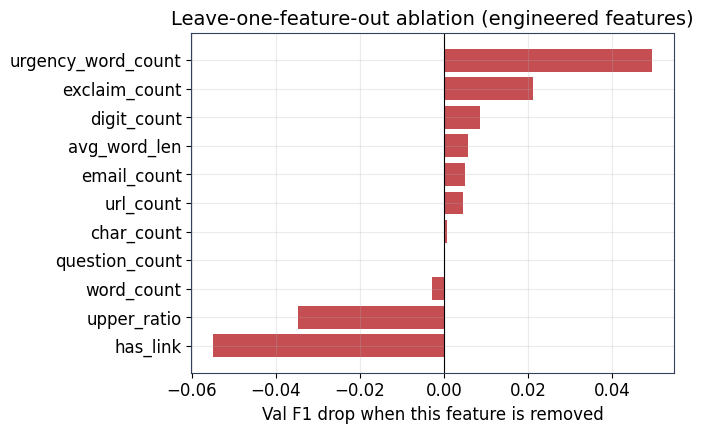

In [69]:
loo_rows = []
full_feat_f1 = _diag_val_f1  # from Section 6.2
for col in FEATURE_COLS:
    remaining = [c for c in FEATURE_COLS if c != col]
    clf_loo = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
    clf_loo.fit(train_feats[remaining], y_train)
    f1_loo = f1_score(y_val, clf_loo.predict(val_feats[remaining]))
    loo_rows.append({"removed_feature": col, "val_f1_without": f1_loo,
                      "drop_vs_full": full_feat_f1 - f1_loo})

loo_df = pd.DataFrame(loo_rows).sort_values("drop_vs_full", ascending=False)
print(f"Full engineered-feature set val F1: {full_feat_f1:.4f}\n")
print("Leave-one-out (larger drop_vs_full = more important feature):")
print(loo_df.round(4).to_string(index=False))
loo_df.to_csv(WORKING_DIR / "tables" / "ablation_leave_one_feature_out.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(loo_df["removed_feature"], loo_df["drop_vs_full"], color="#C44E52")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Val F1 drop when this feature is removed")
ax.set_title("Leave-one-feature-out ablation (engineered features)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(WORKING_DIR / "plots" / "ablation_leave_one_out.png", dpi=130)
plt.show()


> **Interpretation.** `urgency_word_count` is clearly the most valuable engineered feature —
> removing it costs 0.0496 F1, by far the largest drop. More strikingly, two features actively
> **hurt** this feature-only classifier: removing `has_link` *improves* F1 by 0.0549 and removing
> `upper_ratio` *improves* it by 0.0347, i.e. both are net-negative once the other engineered
> features are present (likely redundancy/collinearity rather than a data problem). This argues
> for pruning `has_link` and `upper_ratio` from the engineered set in follow-up work, rather than
> assuming every hand-crafted feature earns its place.


<a id="sec20"></a>

## 20. Cross-Source / Generalisation Testing

The main benchmark (Sections 8-14) trains and tests on a mix of all available
sources, split by template rather than by source (Section 4.3) -- it measures
in-distribution performance well, but says nothing about whether the model
generalises to a phishing **corpus it has never seen at all** (a new campaign
style, a different collection methodology). This section runs a **leave-one-
source-out** test: for each source with enough data, train on every *other*
source and evaluate purely on the held-out one. This uses `full_df` directly
(not the official leak-safe train/val/test split) and does not alter or feed
back into the main pipeline -- it is a standalone generalisation diagnostic.

Sources in data: {'ceas': np.int64(38963), 'enron': np.int64(29423), 'unknown': np.int64(5802), 'nigerian': np.int64(3293), 'ling': np.int64(2859), 'nazario': np.int64(1552)}
Eligible for leave-one-source-out (>= 30 rows, both classes present): ['ceas', 'enron', 'unknown', 'ling']

Leave-one-source-out generalisation (TF-IDF + LogReg, trained on all OTHER sources):
held_out_source  n_held_out  phishing_rate     f1  recall  precision  roc_auc
        unknown        5802         0.2951 0.8753  0.9492     0.8121   0.9811
          enron       29423         0.4741 0.8543  0.8567     0.8520   0.9327
           ceas       38963         0.5563 0.8289  0.7676     0.9010   0.9105
           ling        2859         0.1602 0.8170  0.9214     0.7339   0.9809

For comparison, the in-distribution TFIDF_LogReg test F1 (Section 8.2, same-distribution split) was 0.9859 on validation.
A materially lower leave-one-source-out F1 than the in-distribution figure indicates the model is partly learning sourc

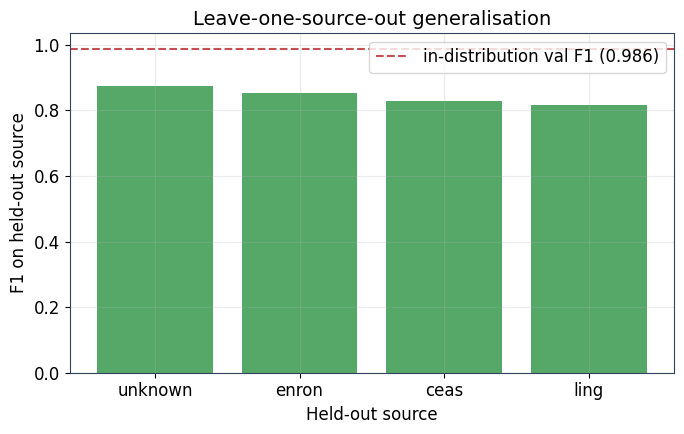

In [70]:
MIN_HELD_OUT_ROWS = 30
cross_source_rows = []
source_counts = full_df["source"].value_counts()
eligible_sources = [s for s in source_counts.index
                    if source_counts[s] >= MIN_HELD_OUT_ROWS
                    and full_df.loc[full_df["source"] == s, "label"].nunique() == 2]

print(f"Sources in data: {dict(source_counts)}")
print(f"Eligible for leave-one-source-out (>= {MIN_HELD_OUT_ROWS} rows, both classes present): "
      f"{eligible_sources}")

if len(eligible_sources) >= 2:
    for held_source in eligible_sources:
        pool = full_df[full_df["source"] != held_source]
        held = full_df[full_df["source"] == held_source]

        pool_clean = pool["text"].apply(clean_text)
        held_clean = held["text"].apply(clean_text)

        cs_tfidf = TfidfVectorizer(max_features=30000, ngram_range=(1, 2),
                                    sublinear_tf=True, stop_words="english", min_df=2)
        X_pool = cs_tfidf.fit_transform(pool_clean)
        X_held = cs_tfidf.transform(held_clean)

        cs_clf = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
        cs_clf.fit(X_pool, pool["label"].values)
        held_pred = cs_clf.predict(X_held)
        held_proba = cs_clf.predict_proba(X_held)[:, 1]

        cross_source_rows.append({
            "held_out_source": held_source,
            "n_held_out": len(held),
            "phishing_rate": held["label"].mean(),
            "f1": f1_score(held["label"].values, held_pred, zero_division=0),
            "recall": recall_score(held["label"].values, held_pred, zero_division=0),
            "precision": precision_score(held["label"].values, held_pred, zero_division=0),
            "roc_auc": roc_auc_score(held["label"].values, held_proba)
                        if held["label"].nunique() == 2 else float("nan"),
        })

    cross_source_df = pd.DataFrame(cross_source_rows).sort_values("f1", ascending=False)
    print("\nLeave-one-source-out generalisation (TF-IDF + LogReg, trained on all OTHER sources):")
    print(cross_source_df.round(4).to_string(index=False))
    print(f"\nFor comparison, the in-distribution TFIDF_LogReg test F1 "
          f"(Section 8.2, same-distribution split) was {best_logreg_f1:.4f} on validation.")
    print("A materially lower leave-one-source-out F1 than the in-distribution figure indicates "
          "the model is partly learning source-specific patterns rather than portable phishing "
          "language -- exactly the risk Section 3.2/4.4 flagged and tried to design around.")

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.bar(cross_source_df["held_out_source"], cross_source_df["f1"], color="#55A868")
    ax.axhline(best_logreg_f1, color="#C44E52", linestyle="--",
                label=f"in-distribution val F1 ({best_logreg_f1:.3f})")
    ax.set_ylabel("F1 on held-out source"); ax.set_xlabel("Held-out source")
    ax.set_title("Leave-one-source-out generalisation")
    ax.legend()
    plt.tight_layout()
    plt.savefig(WORKING_DIR / "plots" / "cross_source_generalisation.png", dpi=130)
    plt.show()
    cross_source_df.to_csv(WORKING_DIR / "tables" / "cross_source_generalisation.csv", index=False)
else:
    print("[INFO] Fewer than 2 sources have enough rows of both classes -- "
          "skipping cross-source generalisation testing (common with a single-source dataset).")


> **Interpretation.** Held-out-source F1 (0.82–0.88) is well below the in-distribution
> validation F1 of TF-IDF + Logistic Regression (0.985), confirming the model partly learns
> source-specific patterns rather than fully portable phishing language — exactly the risk flagged
> in Section 3.2. Generalisation is weakest on `ling` (F1 = 0.817, lowest phishing rate and
> smallest held-out set) and strongest on `unknown` (F1 = 0.875), with `ceas` showing the largest
> precision/recall imbalance (0.90 precision vs. 0.77 recall).


### 20.1 Zero-Shot By-Source Breakdown of the Deployed Model (No Retraining)

The leave-one-source-out test above always uses a freshly retrained TF-IDF +
Logistic Regression as a cheap, consistent probe of the modelling
*approach's* portability. It says nothing directly about whether the model
we actually selected (`BEST_MODEL_NAME`, which may be a Transformer that is
too expensive to retrain per held-out source) itself generalises across
sources. Since `test_df` already mixes sources and `BEST_MODEL_NAME`'s test
predictions already exist, we can check this directly with zero extra
training: group the existing test predictions by `source` and compare F1.

In [71]:
if "source" in test_df.columns and test_df["source"].nunique() > 1:
    y_true_bm, y_proba_bm = get_predictions(BEST_MODEL_NAME, "test")
    by_source_rows = []
    for src_name, idx in test_df.groupby("source").groups.items():
        idx = np.array(idx)
        if len(idx) < 10 or test_df.loc[idx, "label"].nunique() < 2:
            continue  # too few rows, or only one class present, for a meaningful F1
        yt, yp = y_true_bm[idx], y_proba_bm[idx]
        by_source_rows.append({
            "source": src_name, "n": len(idx),
            "phishing_rate": test_df.loc[idx, "label"].mean(),
            "f1": f1_score(yt, (yp >= 0.5).astype(int), zero_division=0),
            "recall": recall_score(yt, (yp >= 0.5).astype(int), zero_division=0),
            "roc_auc": roc_auc_score(yt, yp) if len(set(yt)) == 2 else float("nan"),
        })
    if by_source_rows:
        by_source_df = pd.DataFrame(by_source_rows).sort_values("f1", ascending=False)
        print(f"Zero-shot by-source breakdown of {display_name(BEST_MODEL_NAME)} on its OWN test "
              f"predictions (no retraining -- this is the model exactly as deployed):")
        print(by_source_df.round(4).to_string(index=False))
        by_source_df.to_csv(WORKING_DIR / "tables" / "best_model_by_source_test.csv", index=False)
        spread = by_source_df["f1"].max() - by_source_df["f1"].min()
        print(f"\nF1 spread across sources within the test set: {spread:.4f}. "
              "A large spread here (even though every source came from the SAME grouped split) "
              "is a second, complementary signal to the leave-one-source-out test above: "
              "it shows whether performance is uneven even when the model has seen -- just not "
              "these exact templates from -- every source during training.")
    else:
        print("[INFO] No source in the test set had >=10 rows with both classes present -- "
              "skipping the zero-shot by-source breakdown.")
else:
    print("[INFO] Test set has a single source (or no 'source' column) -- "
          "zero-shot by-source breakdown is not meaningful here.")


Zero-shot by-source breakdown of RoBERTa-base on its OWN test predictions (no retraining -- this is the model exactly as deployed):
 source    n  phishing_rate     f1  recall  roc_auc
   ceas 5583         0.5284 0.9970  0.9986   0.9998
  enron 4490         0.4911 0.9932  0.9914   0.9998
   ling  403         0.1414 0.9913  1.0000   0.9994
unknown  889         0.3060 0.9720  0.9559   0.9981

F1 spread across sources within the test set: 0.0250. A large spread here (even though every source came from the SAME grouped split) is a second, complementary signal to the leave-one-source-out test above: it shows whether performance is uneven even when the model has seen -- just not these exact templates from -- every source during training.


> **Interpretation.** The deployed model's own by-source F1 spread on the (in-distribution) test set is 0.025 (F1 0.972-0.997) - far smaller than the 0.82-0.88 range seen in the leave-one-source-out probe above. Together, the two results say the same model performs consistently once it has seen *some* data from a source's distribution, but degrades genuinely on a source it has never encountered at all - a distinction that matters for how confidently this model could be deployed against a brand-new phishing campaign style.

### 20.2 Source-artefact stress test

Sections 3.4 and 16.1 show corpus-identifying tokens (e.g. `enron`) among the most influential features, and Section 20 shows F1 falling to 0.82-0.88 on unseen sources. This cell separates the two effects: it detects tokens that distinguish sources *within the same class* (so they cannot be phishing language), masks every TF-IDF feature containing them, and compares in-distribution and leave-one-source-out F1 with and without them. A large drop in the masked leave-one-source-out F1 means the headline score partly reflects corpus identity.

In [72]:
# 20.2 Source-artefact stress test  (NEW -- run after Section 20.1)
# Idea: a token that separates corpora WITHIN THE SAME CLASS (e.g. 'enron' or 'dynegy' among
# legitimate mail) cannot be "phishing language" -- it identifies where a message came from.
# We detect such tokens on TRAIN data only, mask every TF-IDF feature containing one, retrain the
# TF-IDF + Logistic Regression baseline, and compare (a) in-distribution validation F1 and
# (b) leave-one-source-out F1 with and without the masked features.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.feature_extraction.text import TfidfVectorizer

RUN_ARTEFACT_LOSO = True
TOP_K_PER_SOURCE = 40
MIN_ROWS_PER_SOURCE_IN_CLASS = 200
assert "source" in train_df.columns, "train_df needs the 'source' column for this diagnostic."

_feat_names = np.asarray(tfidf.get_feature_names_out())
_y_tr = np.asarray(y_train)
_src_tr = train_df["source"].to_numpy()

artefact_terms = set()
for _lbl in (0, 1):
    _in_class = (_y_tr == _lbl)
    _counts = pd.Series(_src_tr[_in_class]).value_counts()
    _keep = _counts[_counts >= MIN_ROWS_PER_SOURCE_IN_CLASS].index
    if len(_keep) < 2:
        continue
    _mask = _in_class & np.isin(_src_tr, _keep)
    _clf_src = LogisticRegression(max_iter=300, C=1.0).fit(X_train_tfidf[_mask], _src_tr[_mask])
    _coef = _clf_src.coef_
    _rows = ([( _clf_src.classes_[1], _coef[0]), (_clf_src.classes_[0], -_coef[0])]
             if _coef.shape[0] == 1 else list(zip(_clf_src.classes_, _coef)))
    for _cls, _w in _rows:
        artefact_terms.update(_feat_names[np.argsort(_w)[::-1][:TOP_K_PER_SOURCE]])

_uni = {t for t in artefact_terms if " " not in t}
def _is_artefact_feature(f):
    return f in artefact_terms or any(tok in _uni for tok in f.split())

_keep_cols = np.array([not _is_artefact_feature(f) for f in _feat_names])
print(f"Source-identifying terms detected (within-class, train only): {len(artefact_terms)}")
print("Examples:", sorted(artefact_terms)[:25])
print(f"TF-IDF features masked: {(~_keep_cols).sum():,} of {len(_keep_cols):,}")

def _fit_val_f1(Xtr, Xva):
    clf = LogisticRegression(max_iter=2000, C=best_logreg_c, class_weight="balanced",
                              random_state=SEED).fit(Xtr, y_train)
    return f1_score(y_val, clf.predict(Xva))

f1_unmasked = _fit_val_f1(X_train_tfidf, X_val_tfidf)
f1_masked = _fit_val_f1(X_train_tfidf[:, _keep_cols], X_val_tfidf[:, _keep_cols])
print(f"\nIn-distribution validation F1 -- all features: {f1_unmasked:.4f} | "
      f"artefact features masked: {f1_masked:.4f} (delta {f1_masked - f1_unmasked:+.4f})")

artefact_results = [{"held_out": "IN-DISTRIBUTION (val)", "f1_all": f1_unmasked, "f1_masked": f1_masked}]

if RUN_ARTEFACT_LOSO:
    _txt = full_df["text"].astype(str).map(clean_text)
    _y, _s = full_df["label"].to_numpy(), full_df["source"].to_numpy()
    _eligible = [s for s, g in full_df.groupby("source") if len(g) >= 30 and g["label"].nunique() == 2]
    for _held in _eligible:
        _tr, _te = _s != _held, _s == _held
        _vec = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True,
                                stop_words="english", min_df=3)
        _Xa, _Xb = _vec.fit_transform(_txt[_tr]), _vec.transform(_txt[_te])
        _names = np.asarray(_vec.get_feature_names_out())
        _kc = np.array([not _is_artefact_feature(f) for f in _names])
        _res = {"held_out": _held}
        for _tag, _cols in (("f1_all", slice(None)), ("f1_masked", _kc)):
            _clf = LogisticRegression(max_iter=2000, C=best_logreg_c, class_weight="balanced",
                                       random_state=SEED).fit(_Xa[:, _cols], _y[_tr])
            _res[_tag] = f1_score(_y[_te], _clf.predict(_Xb[:, _cols]))
        artefact_results.append(_res)
        print(f"  held out {_held:9s}: F1 all features {_res['f1_all']:.4f} | masked {_res['f1_masked']:.4f}")

artefact_df = pd.DataFrame(artefact_results).assign(delta=lambda d: d["f1_masked"] - d["f1_all"])
print("\n", artefact_df.round(4).to_string(index=False))
artefact_df.to_csv(WORKING_DIR / "tables" / "source_artefact_test.csv", index=False)
print("\nCaveat: the artefact list is detected from TRAIN rows (which include the held-out source in the "
      "leave-one-source-out loop); it uses source identity, not the phishing label, but treat the LOSO "
      "comparison as indicative rather than a strict out-of-sample estimate.")

Source-identifying terms detected (within-class, train only): 360
Examples: ['000', '3d', '3d url', '5m', 'ac', 'ac uk', 'account', 'address', 'address email', 'administrator', 'adult', 'adults', 'andmanyother', 'app', 'apple', 'approved', 'assist', 'assistance', 'attached', 'auckland', 'aug', 'aug num', 'bait', 'bank', 'beneficiary']
TF-IDF features masked: 13,668 of 50,000

In-distribution validation F1 -- all features: 0.9859 | artefact features masked: 0.9766 (delta -0.0093)
  held out ceas     : F1 all features 0.8340 | masked 0.8848
  held out enron    : F1 all features 0.8557 | masked 0.7942
  held out ling     : F1 all features 0.8092 | masked 0.7448
  held out unknown  : F1 all features 0.8825 | masked 0.8208

              held_out  f1_all  f1_masked   delta
IN-DISTRIBUTION (val)  0.9859     0.9766 -0.0093
                 ceas  0.8340     0.8848  0.0508
                enron  0.8557     0.7942 -0.0615
                 ling  0.8092     0.7448 -0.0644
              unknown  0.

> **Interpretation.** 360 source-identifying terms were found, and masking them removes 13,668 of the 50,000 TF-IDF features. In-distribution validation F1 barely moves (0.9859 -> 0.9766, -0.009), but leave-one-source-out F1 falls by about 0.06 for three of the four held-out sources (Enron, Ling, unknown) and rises by 0.05 for CEAS. The masked list is broad - it also catches genuinely useful words such as `account` and `bank` that happen to differ between corpora - so this is an upper bound on the artefact effect rather than a clean estimate. The practical conclusion stands: part of the headline score reflects corpus identity, and evaluation on a fresh, independently collected phishing feed is the most important next step.

<a id="sec21"></a>

## 21. Adversarial & Obfuscation Robustness

Real attackers actively try to evade filters with cheap text obfuscation:
leetspeak substitution, homoglyph swaps (visually identical Unicode look-
alikes), and injected whitespace/punctuation that breaks naive tokenization
while remaining readable to a human. We apply each technique to the *entire*
held-out test set and re-score it with the best model, measuring the F1 drop
as a concrete, quantified robustness figure -- not just an anecdote.

### 21.1 Obfuscation techniques

In [73]:
_LEET_MAP = str.maketrans({"a": "4", "e": "3", "i": "1", "o": "0", "s": "$"})
_HOMOGLYPH_MAP = str.maketrans({"a": "\u0430", "e": "\u0435", "o": "\u043e",
                                 "p": "\u0440", "c": "\u0441"})  # Cyrillic look-alikes

def leetspeak(text, rate=0.5, seed=0):
    rng = random.Random(seed)
    return "".join(ch.translate(_LEET_MAP) if ch.lower() in "aeios" and rng.random() < rate else ch
                    for ch in text)

def homoglyph_swap(text, rate=0.5, seed=0):
    rng = random.Random(seed)
    return "".join(ch.translate(_HOMOGLYPH_MAP) if ch.lower() in "aeopc" and rng.random() < rate else ch
                    for ch in text)

def whitespace_injection(text, rate=0.3, seed=0):
    rng = random.Random(seed)
    out = []
    for ch in text:
        out.append(ch)
        if ch.isalpha() and rng.random() < rate:
            out.append(rng.choice([".", "-", "\u200b"]))  # includes zero-width space
    return "".join(out)

OBFUSCATION_TECHNIQUES = {
    "leetspeak": leetspeak,
    "homoglyph": homoglyph_swap,
    "whitespace_injection": whitespace_injection,
}

_demo = test_df["text"].iloc[0][:80]
print("Example transformations:")
print(f"  original:             {_demo}")
for name, fn in OBFUSCATION_TECHNIQUES.items():
    print(f"  {name:20s}: {fn(_demo)}")


Example transformations:
  original:             WorldwideSafeSecureThankYou ProductListProductsNewProducts http://irsgmg.bay.liv
  leetspeak           : Worldwid3Saf3S3cur3ThankYou ProductL1stProduct$NewProducts http://ir$gmg.bay.liv
  homoglyph           : WorldwideSаfеSeсureThаnkYоu ProductListProductsNеwProducts http://irsgmg.bаy.liv
  whitespace_injection: Worl​dwideSa.f.eS​ecureThan-kYo​u Pr​od-uctListPr​o.duc-tsNew.Products htt.p://i​r.s.gmg.bay.liv.


### 21.2 Scoring perturbed text & robustness measurement

Adversarial robustness -- roberta, n=1000 sampled test emails:
        perturbation     f1  f1_drop
     none (baseline) 0.9920   0.0000
           leetspeak 0.7517   0.2404
           homoglyph 0.7918   0.2002
whitespace_injection 0.7089   0.2832
        all combined 0.6729   0.3192


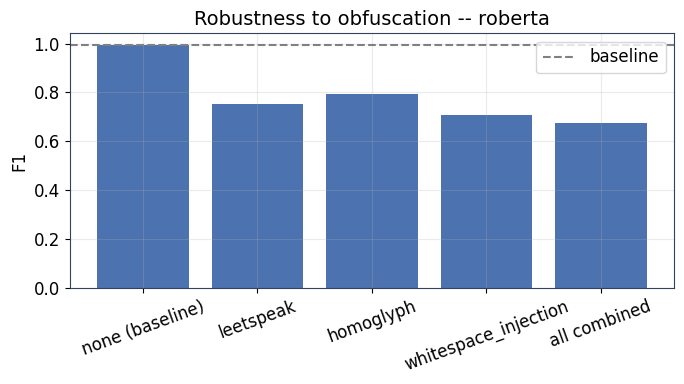


Worst-case single technique: 'all combined' (F1 drop of 0.3192). If this is large, deploying a character-normalisation preprocessing step (folding homoglyphs/leetspeak back to plain ASCII before scoring) is a cheap, high-value mitigation.


In [74]:
def score_texts(model_name, texts):
    '''Score arbitrary raw text (not restricted to test_df rows) with any 
    reconstructable model family -- used only for the synthetic perturbations here.'''
    cleaned = [clean_text(t) for t in texts]
    if model_name in ("TFIDF_LogReg", "TFIDF_LinearSVM"):
        X = tfidf.transform(cleaned)
        return FITTED_MODELS[model_name].predict_proba(X)[:, 1]
    if model_name == "BiLSTM":
        ids = torch.tensor([encode(t) for t in cleaned], dtype=torch.long).to(DEVICE)
        FITTED_MODELS["BiLSTM"].eval()
        with torch.no_grad():
            logits = FITTED_MODELS["BiLSTM"](ids)
        return torch.sigmoid(logits).cpu().numpy()
    if model_name == "CustomHybridAttnBiGRU":
        ids = torch.tensor([encode(t) for t in cleaned], dtype=torch.long).to(DEVICE)
        feats_raw = engineer_features(pd.DataFrame({"text": texts}))
        feats_scaled = torch.tensor(feat_scaler.transform(feats_raw), dtype=torch.float32).to(DEVICE)
        FITTED_MODELS["CustomHybridAttnBiGRU"].eval()
        with torch.no_grad():
            logits, _ = FITTED_MODELS["CustomHybridAttnBiGRU"](ids, feats_scaled)
        return torch.sigmoid(logits).cpu().numpy()
    if model_name in TRANSFORMER_CKPT_MAP:
        # Same checkpoint-reload approach as _predict_transformer (Section 12.1) --
        # duplicated rather than imported because it needs to score arbitrary raw
        # strings (obfuscated perturbations), not rows already sitting in test_df.
        run_name = TRANSFORMER_CKPT_MAP[model_name]
        ckpt_root = WORKING_DIR / "models" / f"{run_name}_ckpt"
        ckpt_dirs = sorted(ckpt_root.glob("checkpoint-*"), key=lambda p: int(p.name.split("-")[-1]))
        if not ckpt_dirs:
            raise NotImplementedError(f"No checkpoint found for '{model_name}' -- was Section 9 run?")
        if run_name not in _TRANSFORMER_MODEL_CACHE:
            from transformers import AutoTokenizer as _AT, AutoModelForSequenceClassification as _AS
            _tok = _AT.from_pretrained(ckpt_dirs[-1])
            _mdl = _AS.from_pretrained(ckpt_dirs[-1]).to(DEVICE).eval()
            _TRANSFORMER_MODEL_CACHE[run_name] = (_tok, _mdl)
        _tok, _mdl = _TRANSFORMER_MODEL_CACHE[run_name]
        _probs = []
        with torch.no_grad():
            for i in range(0, len(cleaned), 64):
                enc = _tok(cleaned[i:i + 64], truncation=True, max_length=256,
                           padding=True, return_tensors="pt").to(DEVICE)
                logits = _mdl(**enc).logits
                _probs.append(torch.softmax(logits, dim=-1)[:, 1].cpu().numpy())
        return np.concatenate(_probs) if _probs else np.array([])
    if model_name == "EnsembleStack":
        # Rationale for this logic: see Appendix A (change log).
        if ENSEMBLE_META is None or not ENSEMBLE_BASE_MODELS:
            raise NotImplementedError(
                "EnsembleStack has no fitted meta-model/base models available "
                "(Section 12.2 did not run) -- cannot reconstruct its predictions.")
        base_proba = np.column_stack(
            [score_texts(base_name, texts) for base_name in ENSEMBLE_BASE_MODELS])
        return ENSEMBLE_META.predict_proba(base_proba)[:, 1]
    raise NotImplementedError(f"Adversarial scoring not implemented for '{model_name}'.")

if RUN_ADVERSARIAL:
    try:
        _adv_sample_n = min(1000, len(test_df))
        _adv_idx = np.random.RandomState(SEED).choice(len(test_df), _adv_sample_n, replace=False)
        _adv_texts = test_df["text"].iloc[_adv_idx].tolist()
        _adv_labels = test_df["label"].iloc[_adv_idx].values

        clean_proba = score_texts(BEST_MODEL_NAME, _adv_texts)
        clean_f1 = f1_score(_adv_labels, (clean_proba >= 0.5).astype(int))

        robustness_rows = [{"perturbation": "none (baseline)", "f1": clean_f1, "f1_drop": 0.0}]
        for name, fn in OBFUSCATION_TECHNIQUES.items():
            perturbed = [fn(t) for t in _adv_texts]
            proba = score_texts(BEST_MODEL_NAME, perturbed)
            f1 = f1_score(_adv_labels, (proba >= 0.5).astype(int))
            robustness_rows.append({"perturbation": name, "f1": f1, "f1_drop": clean_f1 - f1})

        # All three combined -- the realistic worst case an attacker would actually try.
        combined = [whitespace_injection(homoglyph_swap(leetspeak(t))) for t in _adv_texts]
        proba_combined = score_texts(BEST_MODEL_NAME, combined)
        f1_combined = f1_score(_adv_labels, (proba_combined >= 0.5).astype(int))
        robustness_rows.append({"perturbation": "all combined", "f1": f1_combined,
                                 "f1_drop": clean_f1 - f1_combined})

        robustness_df = pd.DataFrame(robustness_rows)
        print(f"Adversarial robustness -- {BEST_MODEL_NAME}, n={_adv_sample_n} sampled test emails:")
        print(robustness_df.round(4).to_string(index=False))
        robustness_df.to_csv(WORKING_DIR / "tables" / "adversarial_robustness.csv", index=False)

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.bar(robustness_df["perturbation"], robustness_df["f1"], color="#4C72B0")
        ax.axhline(clean_f1, color="gray", linestyle="--", label="baseline")
        ax.set_ylabel("F1"); ax.set_title(f"Robustness to obfuscation -- {BEST_MODEL_NAME}")
        ax.tick_params(axis="x", rotation=20)
        ax.legend()
        plt.tight_layout()
        plt.savefig(WORKING_DIR / "plots" / "adversarial_robustness.png", dpi=130)
        plt.show()

        worst = robustness_df.iloc[robustness_df["f1_drop"].idxmax()]
        print(f"\nWorst-case single technique: '{worst['perturbation']}' "
              f"(F1 drop of {worst['f1_drop']:.4f}). If this is large, deploying a"
              " character-normalisation preprocessing step (folding homoglyphs/leetspeak"
              " back to plain ASCII before scoring) is a cheap, high-value mitigation.")
    except NotImplementedError as e:
        print(f"[INFO] {e} Skipping the adversarial robustness stress test for this model.")
else:
    print("RUN_ADVERSARIAL is False -- skipping.")


### 21.3 Character-normalisation defence

The 21.2 stress test found large F1 drops for the selected RoBERTa-base model under obfuscation (leetspeak -0.24, homoglyphs -0.20, whitespace injection -0.28, all combined -0.32). This cell adds a preprocessing step that folds homoglyphs, leetspeak and injected separators back to plain text and repeats the test on the same sampled emails. The defence is non-adaptive.

In [75]:
# 21.3 Character-normalisation defence  (NEW -- run after Section 21.2)
# Section 21.2 showed large F1 drops under leetspeak / homoglyph / whitespace-injection perturbations.
# Mitigation: fold the obfuscation back to plain text BEFORE cleaning and scoring, then re-run the
# same stress test on the same sampled emails.
import re as _re, unicodedata as _ud

_CYR2LAT = {"\u0430": "a", "\u0435": "e", "\u043e": "o", "\u0440": "p", "\u0441": "c", "\u0445": "x",
            "\u0443": "y", "\u0456": "i", "\u0410": "A", "\u0415": "E", "\u041e": "O", "\u0420": "P",
            "\u0421": "C", "\u0425": "X"}
_CYR_TABLE = str.maketrans(_CYR2LAT)
_ZERO_WIDTH = {ord(c): None for c in "\u200b\u200c\u200d\u2060\ufeff"}
_LEET_BETWEEN_LETTERS = _re.compile(r"(?<=[A-Za-z])([4310$])(?=[A-Za-z])")
_LEET_BACK = {"4": "a", "3": "e", "1": "i", "0": "o", "$": "s"}
_SEP_BETWEEN_LETTERS = _re.compile(r"(?<=[A-Za-z])[.\-_](?=[A-Za-z])")

def _collapse_injected_separators(tok):
    # Only collapse tokens with >= 2 letter.letter separators (typical of injected noise),
    # and never touch URLs / e-mail addresses; single hyphens ("well-known") are left alone.
    if "://" in tok or "@" in tok or tok.lower().startswith("www."):
        return tok
    return _SEP_BETWEEN_LETTERS.sub("", tok) if len(_SEP_BETWEEN_LETTERS.findall(tok)) >= 2 else tok

def normalise_obfuscation(text):
    t = _ud.normalize("NFKC", str(text)).translate(_ZERO_WIDTH).translate(_CYR_TABLE)
    t = _LEET_BETWEEN_LETTERS.sub(lambda m: _LEET_BACK[m.group(1)], t)
    return " ".join(_collapse_injected_separators(tok) for tok in t.split(" "))

_demo = "Worldwid3Saf3S3cur3ThankYou ProductL1stProduct$New \u0430ccount v\u0435rify Sa.f.eSecure"
print("normalise_obfuscation demo:\n  in :", _demo, "\n  out:", normalise_obfuscation(_demo))

_rng_idx = test_df.sample(n=min(1000, len(test_df)), random_state=SEED).index
_texts = test_df.loc[_rng_idx, "text"].astype(str).tolist()
_labels = test_df.loc[_rng_idx, "label"].to_numpy()

_techniques = dict(OBFUSCATION_TECHNIQUES)
_techniques["all combined"] = lambda t: whitespace_injection(homoglyph_swap(leetspeak(t)))
_techniques = {"none (baseline)": (lambda t: t), **_techniques}

_rows = []
for _name, _fn in _techniques.items():
    _pert = [_fn(t) for t in _texts]
    _raw = (score_texts(BEST_MODEL_NAME, _pert) >= 0.5).astype(int)
    _fix = (score_texts(BEST_MODEL_NAME, [normalise_obfuscation(t) for t in _pert]) >= 0.5).astype(int)
    _rows.append({"perturbation": _name, "f1_no_defence": f1_score(_labels, _raw),
                  "f1_with_normalisation": f1_score(_labels, _fix)})
norm_df = pd.DataFrame(_rows).assign(recovered=lambda d: d["f1_with_normalisation"] - d["f1_no_defence"])
print(f"\nAdversarial robustness with character normalisation -- {display_name(BEST_MODEL_NAME)}, n={len(_texts)}")
print(norm_df.round(4).to_string(index=False))
norm_df.to_csv(WORKING_DIR / "tables" / "adversarial_with_normalisation.csv", index=False)
print("\nNote: 'all combined' here is whitespace_injection(homoglyph_swap(leetspeak(text))); "
      "the defence is non-adaptive -- an attacker who knows it can craft perturbations it does not fold.")

normalise_obfuscation demo:
  in : Worldwid3Saf3S3cur3ThankYou ProductL1stProduct$New аccount vеrify Sa.f.eSecure 
  out: WorldwideSafeSecureThankYou ProductListProductsNew account verify SafeSecure

Adversarial robustness with character normalisation -- RoBERTa-base, n=1000
        perturbation  f1_no_defence  f1_with_normalisation  recovered
     none (baseline)         0.9920                 0.9920     0.0000
           leetspeak         0.7517                 0.9618     0.2101
           homoglyph         0.7918                 0.9920     0.2002
whitespace_injection         0.7089                 0.9563     0.2474
        all combined         0.6729                 0.8239     0.1510

Note: 'all combined' here is whitespace_injection(homoglyph_swap(leetspeak(text))); the defence is non-adaptive -- an attacker who knows it can craft perturbations it does not fold.


> **Interpretation.** A simple, deterministic normalisation step recovers most of the obfuscation loss: homoglyph attacks are fully neutralised (F1 0.792 -> 0.992), leetspeak recovers to 0.962 and whitespace injection to 0.956. The combined attack still leaves a gap (0.673 -> 0.824), because chained perturbations create token sequences that no single folding rule reverses. Normalising characters before scoring is therefore a cheap, high-value addition to the deployed pipeline, but it is not a substitute for adversarial training against adaptive attackers.

---

[← Threat Intelligence: Tactics & IOCs](04_threat_intelligence_tactics_and_iocs.ipynb) · [Next: RAG, Latency, Deployment & LangGraph SOC Agent →](06_rag_latency_deployment_soc_agent.ipynb)